# Assignment 2 — Model Upgrade & Equity Research Enhancement

## Setup

In [1]:
!pip install pyautogen yfinance matplotlib reportlab pandas -q

import os
import json
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
from autogen import AssistantAgent, UserProxyAgent

C:\Users\wujie\anaconda3\envs\finrobot\lib\site-packages\flaml\__init__.py:20: UserWarning: flaml.automl is not available. Please install flaml[automl] to enable AutoML functionalities.
  warnings.warn("flaml.automl is not available. Please install flaml[automl] to enable AutoML functionalities.")


## API Keys

In [2]:
os.environ["ANTHROPIC_API_KEY"]  = "your_claude_api"
os.environ["GOOGLE_API_KEY"]      = "your_google_api"
os.environ["PERPLEXITY_API_KEY"]  = "your_perplexity_api"
os.environ["OPENROUTER_API_KEY"]  = "your_openrouter_api"

## Model Configurations

All three models routed through OpenRouter for unified API access.

In [3]:
def make_claude_config():
    return {
        "model": "anthropic/claude-sonnet-4.6",
        "api_key": os.getenv("OPENROUTER_API_KEY"),
        "base_url": "https://openrouter.ai/api/v1",
    }

def make_gemini_config():
    return {
        "model": "google/gemini-2.5-pro-preview-05-06",
        "api_key": os.getenv("OPENROUTER_API_KEY"),
        "base_url": "https://openrouter.ai/api/v1",
    }

def make_perplexity_config():
    return {
        "model": "perplexity/sonar-pro",
        "api_key": os.getenv("OPENROUTER_API_KEY"),
        "base_url": "https://openrouter.ai/api/v1",
    }

# Convenience aliases — evaluated NOW (use after setting env vars)
claude_config     = make_claude_config()
gemini_config     = make_gemini_config()
perplexity_config = make_perplexity_config()

# Quick check
print("OPENROUTER_API_KEY set:", bool(os.getenv("OPENROUTER_API_KEY")))
print("Claude model :", claude_config["model"])
print("Gemini model :", gemini_config["model"])
print("Perplexity model:", perplexity_config["model"])

OPENROUTER_API_KEY set: True
Claude model : anthropic/claude-sonnet-4.6
Gemini model : google/gemini-2.5-pro-preview-05-06
Perplexity model: perplexity/sonar-pro


## Agent Factory

> **Fix**: agents are re-initialised per experiment rather than mutating `.llm_config`.
> AutoGen caches config internally, so direct assignment does not reliably change the model.
> A factory function is the correct pattern.

In [4]:
def make_agents(expert_cfg_name, analyst_cfg_name, critic_cfg_name):
    """
    Build fresh agents each experiment.
    Accepts config NAME strings ("claude"/"gemini"/"perplexity") and
    calls the factory functions at runtime so the api_key is read
    from the environment at that moment — not from a cached dict.
    """
    _factories = {
        "claude":     make_claude_config,
        "gemini":     make_gemini_config,
        "perplexity": make_perplexity_config,
    }

    expert = AssistantAgent(
        name="Expert_Investor",
        system_message="""You are a top-tier equity research analyst with 20+ years of experience.

For the given company, provide DEEP reasoning covering:
- Thesis: what is the core bull/bear case?
- Financial quality: revenue growth trajectory, margin profile, FCF conversion
- Competitive moat and positioning vs. peers
- Macro tailwinds / headwinds
- Valuation context (is the current multiple justified?)

Think step-by-step. Be specific with numbers where available.

IMPORTANT: If any financial metric appears inconsistent with known reality (e.g. market cap, revenue scale), flag it explicitly and use your best knowledge of the actual figures instead.""",
        llm_config=_factories[expert_cfg_name](),
    )

    analyst = AssistantAgent(
        name="Data_Analyst",
        system_message="""You are a structured equity research analyst.

Given the expert's thesis, produce a STRUCTURED report with exactly these sections:

## 1. Business Overview
## 2. Financial Snapshot
## 3. Growth Drivers
## 4. Risk Factors
## 5. Valuation Analysis
## 6. Investment Recommendation (BUY / HOLD / SELL with price target rationale)

Be concise but precise. Use numbers and percentages wherever possible.""",
        llm_config=_factories[analyst_cfg_name](),
    )

    critic = AssistantAgent(
        name="Critic_Reviewer",
        system_message="""You are a senior equity research editor and risk officer.

Review the structured report and check for:
- Logical consistency between thesis and recommendation
- Missing or underweighted risks
- Unsupported claims or vague statements
- Any financial figures that appear inconsistent

Return the FINAL POLISHED REPORT incorporating all corrections.
Keep the same section structure. Add a final ## 7. Critic Notes section summarising changes made.""",
        llm_config=_factories[critic_cfg_name](),
    )

    return expert, analyst, critic

## Enhanced Financial Metrics

Expanded from 3 to 15+ indicators covering valuation, profitability, leverage, and momentum.

In [5]:
def compute_metrics(ticker: str) -> dict:
    """Fetch comprehensive financial metrics via yfinance."""
    stock = yf.Ticker(ticker)
    info  = stock.info

    # ── Valuation ────────────────────────────────────────────────────────────
    pe_ratio        = info.get("trailingPE")
    forward_pe      = info.get("forwardPE")
    peg_ratio       = info.get("pegRatio")
    pb_ratio        = info.get("priceToBook")
    ps_ratio        = info.get("priceToSalesTrailing12Months")
    ev_ebitda       = info.get("enterpriseToEbitda")
    market_cap      = info.get("marketCap")

    # ── Profitability ─────────────────────────────────────────────────────────
    gross_margin    = info.get("grossMargins")
    operating_margin= info.get("operatingMargins")
    net_margin      = info.get("profitMargins")
    roe             = info.get("returnOnEquity")
    roa             = info.get("returnOnAssets")

    # ── Growth ───────────────────────────────────────────────────────────────
    revenue_growth  = info.get("revenueGrowth")
    earnings_growth = info.get("earningsGrowth")
    revenue_ttm     = info.get("totalRevenue")

    # ── Cash flow & balance sheet ─────────────────────────────────────────────
    fcf             = info.get("freeCashflow")
    total_debt      = info.get("totalDebt")
    cash            = info.get("totalCash")
    debt_to_equity  = info.get("debtToEquity")
    current_ratio   = info.get("currentRatio")

    # ── Earnings surprise (most recent quarter) ───────────────────────────────
    try:
        earnings_hist   = stock.earnings_history
        if earnings_hist is not None and not earnings_hist.empty:
            latest      = earnings_hist.iloc[-1]
            eps_estimate= latest.get("epsEstimate")
            eps_actual  = latest.get("epsActual")
            surprise_pct= latest.get("surprisePercent")
        else:
            eps_estimate = eps_actual = surprise_pct = None
    except Exception:
        eps_estimate = eps_actual = surprise_pct = None

    # ── Analyst consensus ─────────────────────────────────────────────────────
    target_price    = info.get("targetMeanPrice")
    current_price   = info.get("currentPrice")
    analyst_rating  = info.get("recommendationMean")  # 1=Strong Buy, 5=Sell
    num_analysts    = info.get("numberOfAnalystOpinions")

    def fmt_pct(v):
        return f"{v*100:.1f}%" if v is not None else "N/A"
    def fmt_m(v):
        return f"${v/1e9:.2f}B" if v is not None else "N/A"

    return {
        # Valuation
        "trailing_pe":       pe_ratio,
        "forward_pe":        forward_pe,
        "peg_ratio":         peg_ratio,
        "price_to_book":     pb_ratio,
        "price_to_sales":    ps_ratio,
        "ev_ebitda":         ev_ebitda,
        "market_cap":        fmt_m(market_cap),
        # Profitability
        "gross_margin":      fmt_pct(gross_margin),
        "operating_margin":  fmt_pct(operating_margin),
        "net_margin":        fmt_pct(net_margin),
        "roe":               fmt_pct(roe),
        "roa":               fmt_pct(roa),
        # Growth
        "revenue_growth_yoy":fmt_pct(revenue_growth),
        "earnings_growth_yoy":fmt_pct(earnings_growth),
        "revenue_ttm":       fmt_m(revenue_ttm),
        # Cash / Debt
        "free_cash_flow":    fmt_m(fcf),
        "total_debt":        fmt_m(total_debt),
        "cash_and_equiv":    fmt_m(cash),
        "debt_to_equity":    debt_to_equity,
        "current_ratio":     current_ratio,
        # Earnings surprise
        "eps_estimate":      eps_estimate,
        "eps_actual":        eps_actual,
        "earnings_surprise_pct": fmt_pct(surprise_pct) if isinstance(surprise_pct, float) else "N/A",
        # Analyst consensus
        "analyst_target_price": target_price,
        "current_price":     current_price,
        "analyst_rating_mean": analyst_rating,
        "num_analysts":      num_analysts,
    }

## Chart Generation

In [6]:
def generate_chart(ticker: str) -> str:
    """Download 1-year OHLCV and plot price + 50/200-day MAs with volume bar."""
    data = yf.download(ticker, period="1y", auto_adjust=True)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), gridspec_kw={"height_ratios": [3, 1]})
    fig.suptitle(f"{ticker} — 1-Year Price Chart", fontsize=13)

    close = data["Close"].squeeze()
    ax1.plot(data.index, close,           label="Close",   linewidth=1.5)
    ax1.plot(data.index, close.rolling(50).mean(),  label="MA50",    linestyle="--", linewidth=1)
    ax1.plot(data.index, close.rolling(200).mean(), label="MA200",   linestyle=":",  linewidth=1)
    ax1.set_ylabel("Price (USD)")
    ax1.legend(fontsize=8)
    ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
    ax1.grid(alpha=0.3)

    volume = data["Volume"].squeeze()
    ax2.bar(data.index, volume, color="steelblue", alpha=0.5, width=1)
    ax2.set_ylabel("Volume")
    ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    path = f"{ticker}_price.png"
    plt.savefig(path, dpi=120)
    plt.close()
    return path

## Track B — Claude-Inspired Enhancement: Investment Thesis Module

This module is inspired by Anthropic's equity-research workflow design, specifically:
- **Structured thesis generation** before free-form analysis begins
- **Catalyst tracking**: near-term events that could move the stock
- **Earnings surprise analysis**: quantifying how recent results deviated from consensus
- **Bear/bull duality**: explicitly requiring both sides before a recommendation

The `InvestmentThesisAgent` runs *before* the Expert, seeding the pipeline with a structured thesis frame.

In [7]:
def make_thesis_agent(cfg_name):
    """
    Track B enhancement: Investment Thesis Agent.

    Inspired by Anthropic's equity-research plugin design:
    - Forces structured bull/bear framing before analysis
    - Extracts catalysts and earnings surprise context
    - Provides the downstream Expert with a richer starting frame
    """
    return AssistantAgent(
        name="Thesis_Agent",
        system_message="""You are an investment thesis specialist.

Given a company ticker and its financial metrics, produce a concise INVESTMENT THESIS BRIEF with these sections:

## THESIS BRIEF: {TICKER}

### Bull Case (3 key points)
- ...

### Bear Case (3 key points)
- ...

### Key Catalysts (next 6-12 months)
List specific, time-bound events that could materially move the stock:
e.g. product launches, earnings dates, regulatory decisions, macro shifts.

### Earnings Surprise Analysis
Based on the eps_estimate vs eps_actual data:
- Was the last quarter a beat, miss, or in-line?
- What does the surprise pattern suggest about guidance reliability?

### One-Line Thesis Summary
A single sentence capturing the core investment case.

Be specific and use the provided metrics. Do not pad with generic statements.""",
        llm_config={"claude": make_claude_config, "gemini": make_gemini_config, "perplexity": make_perplexity_config}[cfg_name](),
    )


def run_thesis_stage(thesis_agent, ticker: str, metrics: dict) -> str:
    """Run the thesis agent and return its output as a string."""
    metrics_str = json.dumps(metrics, indent=2)
    prompt = f"""
Company: {ticker}

Financial Metrics:
{metrics_str}

Produce the Investment Thesis Brief as instructed.
"""
    reply = thesis_agent.generate_reply(
        messages=[{"role": "user", "content": prompt}]
    )
    return reply if isinstance(reply, str) else str(reply)

## Full Pipeline (Track A + Track B)

In [8]:
def run_pipeline(ticker: str, expert_cfg_name: str, analyst_cfg_name: str, critic_cfg_name: str) -> dict:
    """
    Full 4-stage pipeline:
      Stage 0 (Track B): Investment Thesis Agent
      Stage 1:           Expert Investor
      Stage 2:           Data Analyst
      Stage 3:           Critic Reviewer
    Accepts config name strings so factory fns are called fresh each run.
    """
    metrics    = compute_metrics(ticker)
    chart_path = generate_chart(ticker)

    thesis_agent            = make_thesis_agent(expert_cfg_name)
    expert, analyst, critic = make_agents(expert_cfg_name, analyst_cfg_name, critic_cfg_name)

    # Stage 0: Thesis
    thesis_out = run_thesis_stage(thesis_agent, ticker, metrics)

    # Stage 1: Expert seeded with thesis
    expert_prompt = f"""
Company: {ticker}

=== INVESTMENT THESIS BRIEF ===
{thesis_out}

=== FINANCIAL METRICS ===
{json.dumps(metrics, indent=2)}

Based on the thesis brief and metrics above, provide your deep expert analysis.
"""
    expert_out = expert.generate_reply(messages=[{"role": "user", "content": expert_prompt}])
    expert_out = expert_out if isinstance(expert_out, str) else str(expert_out)

    # Stage 2: Analyst
    analyst_out = analyst.generate_reply(messages=[{"role": "user", "content": expert_out}])
    analyst_out = analyst_out if isinstance(analyst_out, str) else str(analyst_out)

    # Stage 3: Critic
    critic_out = critic.generate_reply(messages=[{"role": "user", "content": analyst_out}])
    critic_out = critic_out if isinstance(critic_out, str) else str(critic_out)

    return {
        "ticker":       ticker,
        "metrics":      metrics,
        "chart_path":   chart_path,
        "thesis":       thesis_out,
        "expert":       expert_out,
        "analyst":      analyst_out,
        "final_report": critic_out,
    }

## Run Experiments

Four experiment configurations — including Perplexity this time.

| Config | Expert | Analyst | Critic |
|---|---|---|---|
| Claude_Only | Claude | Claude | Claude |
| Hybrid_Claude_Gemini | Claude | Gemini | Claude |
| Gemini_Only | Gemini | Gemini | Gemini |
| Hybrid_Perplexity | Perplexity | Claude | Claude |

In [9]:
tickers = ["NVDA", "AMD", "INTC", "AAPL", "GOOGL"]

# Each tuple: (expert_model, analyst_model, critic_model) as name strings
experiments = {
    "Claude_Only":          ("claude",      "claude",  "claude"),
    "Hybrid_Claude_Gemini": ("claude",      "gemini",  "claude"),
    "Gemini_Only":          ("gemini",      "gemini",  "gemini"),
    "Hybrid_Perplexity":    ("perplexity",  "claude",  "claude"),
}

results = {}

for exp_name, (expert_name, analyst_name, critic_name) in experiments.items():
    print(f"\n{'='*60}")
    print(f"Experiment: {exp_name}")
    print(f"  Expert={expert_name}  Analyst={analyst_name}  Critic={critic_name}")
    print(f"{'='*60}")
    results[exp_name] = {}

    for ticker in tickers:
        print(f"  → {ticker} ...", end=" ", flush=True)
        try:
            results[exp_name][ticker] = run_pipeline(
                ticker, expert_name, analyst_name, critic_name
            )
            print("done")
        except Exception as e:
            print(f"ERROR: {e}")
            results[exp_name][ticker] = {"error": str(e)}

print("\nAll experiments complete.")


Experiment: Claude_Only
  Expert=claude  Analyst=claude  Critic=claude
  → NVDA ... 

[*********************100%***********************]  1 of 1 completed


[autogen.oai.client: 04-30 11:28:29] {329} WARNING - Model anthropic/claude-4.6-sonnet-20260217 is not found. The cost will be 0. In your config_list, add field {"price" : [prompt_price_per_1k, completion_token_price_per_1k]} for customized pricing.
[autogen.oai.client: 04-30 11:30:57] {329} WARNING - Model anthropic/claude-4.6-sonnet-20260217 is not found. The cost will be 0. In your config_list, add field {"price" : [prompt_price_per_1k, completion_token_price_per_1k]} for customized pricing.
[autogen.oai.client: 04-30 11:32:27] {329} WARNING - Model anthropic/claude-4.6-sonnet-20260217 is not found. The cost will be 0. In your config_list, add field {"price" : [prompt_price_per_1k, completion_token_price_per_1k]} for customized pricing.
[autogen.oai.client: 04-30 11:35:12] {329} WARNING - Model anthropic/claude-4.6-sonnet-20260217 is not found. The cost will be 0. In your config_list, add field {"price" : [prompt_price_per_1k, completion_token_price_per_1k]} for customized pricing.


[*********************100%***********************]  1 of 1 completed


[autogen.oai.client: 04-30 11:35:38] {329} WARNING - Model anthropic/claude-4.6-sonnet-20260217 is not found. The cost will be 0. In your config_list, add field {"price" : [prompt_price_per_1k, completion_token_price_per_1k]} for customized pricing.
[autogen.oai.client: 04-30 11:37:40] {329} WARNING - Model anthropic/claude-4.6-sonnet-20260217 is not found. The cost will be 0. In your config_list, add field {"price" : [prompt_price_per_1k, completion_token_price_per_1k]} for customized pricing.
[autogen.oai.client: 04-30 11:39:00] {329} WARNING - Model anthropic/claude-4.6-sonnet-20260217 is not found. The cost will be 0. In your config_list, add field {"price" : [prompt_price_per_1k, completion_token_price_per_1k]} for customized pricing.
[autogen.oai.client: 04-30 11:41:41] {329} WARNING - Model anthropic/claude-4.6-sonnet-20260217 is not found. The cost will be 0. In your config_list, add field {"price" : [prompt_price_per_1k, completion_token_price_per_1k]} for customized pricing.


...

[autogen.oai.client: 04-30 12:53:12] {329} WARNING - Model perplexity/sonar-pro is not found. The cost will be 0. In your config_list, add field {"price" : [prompt_price_per_1k, completion_token_price_per_1k]} for customized pricing.
[autogen.oai.client: 04-30 12:53:28] {329} WARNING - Model perplexity/sonar-pro is not found. The cost will be 0. In your config_list, add field {"price" : [prompt_price_per_1k, completion_token_price_per_1k]} for customized pricing.
[autogen.oai.client: 04-30 12:54:29] {329} WARNING - Model anthropic/claude-4.6-sonnet-20260217 is not found. The cost will be 0. In your config_list, add field {"price" : [prompt_price_per_1k, completion_token_price_per_1k]} for customized pricing.
[autogen.oai.client: 04-30 12:56:41] {329} WARNING - Model anthropic/claude-4.6-sonnet-20260217 is not found. The cost will be 0. In your config_list, add field {"price" : [prompt_price_per_1k, completion_token_price_per_1k]} for customized pricing.
done
  → AAPL ... 

[*********************100%***********************]  1 of 1 completed


[autogen.oai.client: 04-30 12:56:51] {329} WARNING - Model perplexity/sonar-pro is not found. The cost will be 0. In your config_list, add field {"price" : [prompt_price_per_1k, completion_token_price_per_1k]} for customized pricing.
[autogen.oai.client: 04-30 12:57:05] {329} WARNING - Model perplexity/sonar-pro is not found. The cost will be 0. In your config_list, add field {"price" : [prompt_price_per_1k, completion_token_price_per_1k]} for customized pricing.
[autogen.oai.client: 04-30 12:58:26] {329} WARNING - Model anthropic/claude-4.6-sonnet-20260217 is not found. The cost will be 0. In your config_list, add field {"price" : [prompt_price_per_1k, completion_token_price_per_1k]} for customized pricing.
[autogen.oai.client: 04-30 13:01:00] {329} WARNING - Model anthropic/claude-4.6-sonnet-20260217 is not found. The cost will be 0. In your config_list, add field {"price" : [prompt_price_per_1k, completion_token_price_per_1k]} for customized pricing.
done
  → GOOGL ... 

[*********************100%***********************]  1 of 1 completed


[autogen.oai.client: 04-30 13:01:14] {329} WARNING - Model perplexity/sonar-pro is not found. The cost will be 0. In your config_list, add field {"price" : [prompt_price_per_1k, completion_token_price_per_1k]} for customized pricing.
[autogen.oai.client: 04-30 13:01:35] {329} WARNING - Model perplexity/sonar-pro is not found. The cost will be 0. In your config_list, add field {"price" : [prompt_price_per_1k, completion_token_price_per_1k]} for customized pricing.
[autogen.oai.client: 04-30 13:02:46] {329} WARNING - Model anthropic/claude-4.6-sonnet-20260217 is not found. The cost will be 0. In your config_list, add field {"price" : [prompt_price_per_1k, completion_token_price_per_1k]} for customized pricing.
[autogen.oai.client: 04-30 13:05:16] {329} WARNING - Model anthropic/claude-4.6-sonnet-20260217 is not found. The cost will be 0. In your config_list, add field {"price" : [prompt_price_per_1k, completion_token_price_per_1k]} for customized pricing.
done

All experiments complete.


## Save Results

In [10]:
# Serialise results (metrics + text stages; skip chart_path for JSON)
def serialisable(obj):
    if isinstance(obj, dict):
        return {k: serialisable(v) for k, v in obj.items() if k != "chart_path"}
    return obj

with open("results.json", "w", encoding="utf-8") as f:
    json.dump(serialisable(results), f, indent=2, ensure_ascii=False)
print("results.json saved.")

results.json saved.


## Save Individual Text Reports

In [11]:
def save_reports(results):
    for exp_name, companies in results.items():
        for ticker, data in companies.items():
            if "error" in data:
                continue
            filename = f"{exp_name}_{ticker}.txt"
            with open(filename, "w", encoding="utf-8") as f:
                f.write(f"{'='*70}\n")
                f.write(f"  {ticker} Equity Research Report\n")
                f.write(f"  Experiment: {exp_name}\n")
                f.write(f"{'='*70}\n\n")
                f.write("=== INVESTMENT THESIS BRIEF ===\n")
                f.write(data.get("thesis", "") + "\n\n")
                f.write("=== EXPERT ANALYSIS ===\n")
                f.write(data.get("expert", "") + "\n\n")
                f.write("=== STRUCTURED REPORT ===\n")
                f.write(data.get("analyst", "") + "\n\n")
                f.write("=== FINAL REVIEWED REPORT ===\n")
                f.write(data.get("final_report", "") + "\n")

save_reports(results)
print("Text reports saved.")

Text reports saved.


## Export PDF Reports

In [12]:
from reportlab.platypus import (
    SimpleDocTemplate, Paragraph, Image, Spacer,
    HRFlowable, Table, TableStyle, PageBreak
)
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.units import inch
from reportlab.lib import colors
from reportlab.lib.enums import TA_LEFT, TA_CENTER
import re, os

# ── Style definitions ──────────────────────────────────────────────────────
def build_styles():
    base = getSampleStyleSheet()

    styles = {
        "title": ParagraphStyle(
            "ReportTitle",
            fontSize=22, leading=28, spaceAfter=4,
            textColor=colors.HexColor("#003366"),
            fontName="Helvetica-Bold", alignment=TA_CENTER,
        ),
        "subtitle": ParagraphStyle(
            "Subtitle",
            fontSize=11, leading=14, spaceAfter=14,
            textColor=colors.HexColor("#555555"),
            fontName="Helvetica", alignment=TA_CENTER,
        ),
        "stage_heading": ParagraphStyle(
            "StageHeading",
            fontSize=14, leading=18, spaceBefore=18, spaceAfter=6,
            textColor=colors.HexColor("#003366"),
            fontName="Helvetica-Bold",
        ),
        "h1": ParagraphStyle(
            "H1", fontSize=13, leading=17, spaceBefore=14, spaceAfter=4,
            textColor=colors.HexColor("#003366"), fontName="Helvetica-Bold",
        ),
        "h2": ParagraphStyle(
            "H2", fontSize=11, leading=15, spaceBefore=10, spaceAfter=3,
            textColor=colors.HexColor("#1a5276"), fontName="Helvetica-Bold",
        ),
        "h3": ParagraphStyle(
            "H3", fontSize=10, leading=14, spaceBefore=8, spaceAfter=2,
            textColor=colors.HexColor("#2e4057"), fontName="Helvetica-BoldOblique",
        ),
        "body": ParagraphStyle(
            "Body", fontSize=9, leading=13, spaceAfter=4,
            fontName="Helvetica", textColor=colors.HexColor("#222222"),
        ),
        "bullet": ParagraphStyle(
            "Bullet", fontSize=9, leading=13, spaceAfter=3,
            fontName="Helvetica", leftIndent=16, firstLineIndent=0,
            textColor=colors.HexColor("#222222"),
        ),
    }
    return styles


def clean_inline(text: str) -> str:
    """Convert inline markdown (**bold**, *italic*) to ReportLab XML tags."""
    # Bold + italic: ***text***
    text = re.sub(r'\*{3}(.+?)\*{3}', r'<b><i>\1</i></b>', text)
    # Bold: **text**
    text = re.sub(r'\*{2}(.+?)\*{2}', r'<b>\1</b>', text)
    # Italic: *text*
    text = re.sub(r'\*(.+?)\*', r'<i>\1</i>', text)
    # Inline code: `text`
    text = re.sub(r'`(.+?)`', r'<font name="Courier">\1</font>', text)
    return text


def safe_xml(text: str) -> str:
    """Escape XML special chars, then apply inline markdown."""
    text = text.replace('&', '&amp;').replace('<', '&lt;').replace('>', '&gt;')
    return clean_inline(text)


def parse_markdown_to_story(md_text: str, styles: dict) -> list:
    """
    Convert a markdown string into a list of ReportLab flowables.
    Handles: # headings, ## headings, ### headings, - bullets, plain paragraphs,
    | tables |, and ---- horizontal rules.
    """
    story = []
    lines = md_text.split('\n')
    i = 0

    while i < len(lines):
        line = lines[i]
        stripped = line.strip()

        # ── Blank line ─────────────────────────────────────────────────────
        if not stripped:
            i += 1
            continue

        # ── Horizontal rule ─────────────────────────────────────────────────
        if re.match(r'^-{3,}$|^={3,}$', stripped):
            story.append(HRFlowable(width="100%", thickness=0.5,
                                    color=colors.lightgrey, spaceAfter=4))
            i += 1
            continue

        # ── Headings ────────────────────────────────────────────────────────
        if stripped.startswith('### '):
            story.append(Paragraph(safe_xml(stripped[4:]), styles['h3']))
            i += 1
            continue
        if stripped.startswith('## '):
            story.append(Paragraph(safe_xml(stripped[3:]), styles['h2']))
            i += 1
            continue
        if stripped.startswith('# '):
            story.append(Paragraph(safe_xml(stripped[2:]), styles['h1']))
            i += 1
            continue

        # ── Bullet point (-, *, •) ──────────────────────────────────────────
        if re.match(r'^[-*•]\s+', stripped):
            content = re.sub(r'^[-*•]\s+', '', stripped)
            story.append(Paragraph('• ' + safe_xml(content), styles['bullet']))
            i += 1
            continue

        # ── Numbered list ───────────────────────────────────────────────────
        if re.match(r'^\d+\.\s+', stripped):
            content = re.sub(r'^\d+\.\s+', '', stripped)
            story.append(Paragraph('• ' + safe_xml(content), styles['bullet']))
            i += 1
            continue

        # ── Table (lines starting with |) ───────────────────────────────────
        if stripped.startswith('|'):
            table_lines = []
            while i < len(lines) and lines[i].strip().startswith('|'):
                table_lines.append(lines[i].strip())
                i += 1
            # Filter out separator rows (|---|---|)
            data_rows = [
                row for row in table_lines
                if not re.match(r'^\|[-:\s|]+\|$', row)
            ]
            if data_rows:
                table_data = []
                for row in data_rows:
                    cells = [c.strip() for c in row.strip('|').split('|')]
                    table_data.append(cells)
                if table_data:
                    # Determine column count from widest row
                    max_cols = max(len(r) for r in table_data)
                    for row in table_data:
                        while len(row) < max_cols:
                            row.append('')
                    # Convert cells to Paragraphs
                    cell_style = ParagraphStyle(
                        'TableCell', fontSize=8, leading=11, fontName='Helvetica'
                    )
                    header_style = ParagraphStyle(
                        'TableHeader', fontSize=8, leading=11,
                        fontName='Helvetica-Bold',
                        textColor=colors.white
                    )
                    pdf_data = []
                    for r_idx, row in enumerate(table_data):
                        s = header_style if r_idx == 0 else cell_style
                        pdf_data.append([
                            Paragraph(safe_xml(cell), s) for cell in row
                        ])
                    col_w = (6.5 * inch) / max_cols
                    t = Table(pdf_data, colWidths=[col_w] * max_cols,
                              repeatRows=1)
                    t.setStyle(TableStyle([
                        ('BACKGROUND', (0,0), (-1,0), colors.HexColor('#003366')),
                        ('ROWBACKGROUNDS', (0,1), (-1,-1),
                         [colors.HexColor('#f0f4f8'), colors.white]),
                        ('GRID', (0,0), (-1,-1), 0.4, colors.HexColor('#cccccc')),
                        ('VALIGN', (0,0), (-1,-1), 'TOP'),
                        ('TOPPADDING', (0,0), (-1,-1), 4),
                        ('BOTTOMPADDING', (0,0), (-1,-1), 4),
                        ('LEFTPADDING', (0,0), (-1,-1), 6),
                        ('RIGHTPADDING', (0,0), (-1,-1), 6),
                    ]))
                    story.append(t)
                    story.append(Spacer(1, 8))
            continue

        # ── Plain paragraph ──────────────────────────────────────────────────
        story.append(Paragraph(safe_xml(stripped), styles['body']))
        story.append(Spacer(1, 2))
        i += 1

    return story


def txt_to_pdf(exp_name: str, ticker: str, data: dict):
    pdf_file = f"{exp_name}_{ticker}_report.pdf"
    styles   = build_styles()

    doc = SimpleDocTemplate(
        pdf_file,
        leftMargin=0.75*inch, rightMargin=0.75*inch,
        topMargin=0.75*inch,  bottomMargin=0.75*inch,
    )
    story = []

    # ── Cover ────────────────────────────────────────────────────────────────
    story.append(Spacer(1, 0.3*inch))
    story.append(Paragraph(f"{ticker} — Equity Research Report", styles['title']))
    story.append(Paragraph(f"Experiment: {exp_name}", styles['subtitle']))
    story.append(HRFlowable(width="100%", thickness=2,
                             color=colors.HexColor("#003366"), spaceAfter=12))

    # ── Price chart ──────────────────────────────────────────────────────────
    chart_path = data.get("chart_path", f"{ticker}_price.png")
    if os.path.exists(chart_path):
        story.append(Image(chart_path, width=5.5*inch, height=3.3*inch))
        story.append(Spacer(1, 14))

    # ── Four content sections ─────────────────────────────────────────────────
    sections = [
        ("Investment Thesis Brief", data.get("thesis", "")),
        ("Expert Analysis",         data.get("expert", "")),
        ("Structured Report",       data.get("analyst", "")),
        ("Final Reviewed Report",   data.get("final_report", "")),
    ]

    for heading, content in sections:
        story.append(Paragraph(heading, styles['stage_heading']))
        story.append(HRFlowable(width="100%", thickness=1,
                                 color=colors.HexColor("#003366"), spaceAfter=6))
        story.extend(parse_markdown_to_story(content, styles))
        story.append(Spacer(1, 10))
        story.append(PageBreak())

    doc.build(story)
    print(f"  PDF saved: {pdf_file}")


# ── Re-generate all PDFs ──────────────────────────────────────────────────
for exp_name, companies in results.items():
    for ticker, data in companies.items():
        if "error" not in data:
            txt_to_pdf(exp_name, ticker, data)

  PDF saved: Claude_Only_NVDA_report.pdf
  PDF saved: Claude_Only_AMD_report.pdf
  PDF saved: Claude_Only_INTC_report.pdf
  PDF saved: Claude_Only_AAPL_report.pdf
  PDF saved: Claude_Only_GOOGL_report.pdf
  PDF saved: Hybrid_Claude_Gemini_AMD_report.pdf
  PDF saved: Hybrid_Claude_Gemini_INTC_report.pdf
  PDF saved: Hybrid_Claude_Gemini_AAPL_report.pdf
  PDF saved: Hybrid_Claude_Gemini_GOOGL_report.pdf
  PDF saved: Gemini_Only_NVDA_report.pdf
  PDF saved: Gemini_Only_AMD_report.pdf
  PDF saved: Gemini_Only_INTC_report.pdf
  PDF saved: Gemini_Only_AAPL_report.pdf
  PDF saved: Gemini_Only_GOOGL_report.pdf
  PDF saved: Hybrid_Perplexity_NVDA_report.pdf
  PDF saved: Hybrid_Perplexity_AMD_report.pdf
  PDF saved: Hybrid_Perplexity_INTC_report.pdf
  PDF saved: Hybrid_Perplexity_AAPL_report.pdf
  PDF saved: Hybrid_Perplexity_GOOGL_report.pdf


## Experiment Comparison Analysis

Quantitative scoring across four dimensions:
- **Length** — proxy for analytical depth
- **Structure score** — presence of required sections
- **Risk coverage** — number of distinct risks mentioned
- **Specificity** — count of numeric figures cited

In [13]:
import re

REQUIRED_SECTIONS = [
    "business overview", "financial", "growth", "risk",
    "valuation", "recommendation", "investment thesis", "catalyst"
]

def score_report(text: str) -> dict:
    """Score a final report on four quantitative dimensions."""
    text_lower = text.lower()

    # 1. Length (word count)
    word_count = len(text.split())

    # 2. Section coverage (0–8)
    section_hits = sum(1 for s in REQUIRED_SECTIONS if s in text_lower)

    # 3. Risk coverage: count sentences containing risk keywords
    risk_keywords = ["risk", "downside", "headwind", "challenge",
                     "competition", "regulatory", "macro", "debt"]
    risk_sentences = [s for s in text.split(".")
                      if any(k in s.lower() for k in risk_keywords)]
    risk_count = len(risk_sentences)

    # 4. Specificity: count numeric mentions (%, $, numbers with units)
    numeric_matches = re.findall(r"\b\d+\.?\d*\s*[%$BMx]", text)
    specificity = len(numeric_matches)

    return {
        "word_count":      word_count,
        "section_coverage": section_hits,
        "risk_coverage":   risk_count,
        "specificity":     specificity,
    }


def compare_experiments(results: dict) -> pd.DataFrame:
    rows = []
    for exp_name, companies in results.items():
        for ticker, data in companies.items():
            if "error" in data:
                continue
            final = data.get("final_report", "")
            scores = score_report(final)
            rows.append({
                "experiment":  exp_name,
                "ticker":      ticker,
                **scores,
            })
    return pd.DataFrame(rows)


# ── Build comparison table ──────────────────────────────────────────────────
df_scores = compare_experiments(results)
print("\nPer-report scores:")
print(df_scores.to_string(index=False))

print("\nAveraged by experiment:")
summary = df_scores.groupby("experiment")[[
    "word_count", "section_coverage", "risk_coverage", "specificity"
]].mean().round(1)
print(summary.to_string())


Per-report scores:
          experiment ticker  word_count  section_coverage  risk_coverage  specificity
         Claude_Only   NVDA        3856                 7             31          157
         Claude_Only    AMD        3932                 6             47          144
         Claude_Only   INTC        5328                 7             43          235
         Claude_Only   AAPL        4294                 8             55          226
         Claude_Only  GOOGL        4287                 7             33          194
Hybrid_Claude_Gemini    AMD        2912                 7             33           84
Hybrid_Claude_Gemini   INTC        3138                 8             48           80
Hybrid_Claude_Gemini   AAPL        2472                 7             33           84
Hybrid_Claude_Gemini  GOOGL        3777                 8             48          120
         Gemini_Only   NVDA        1307                 7             14           14
         Gemini_Only    AMD       

## Visualise Comparison

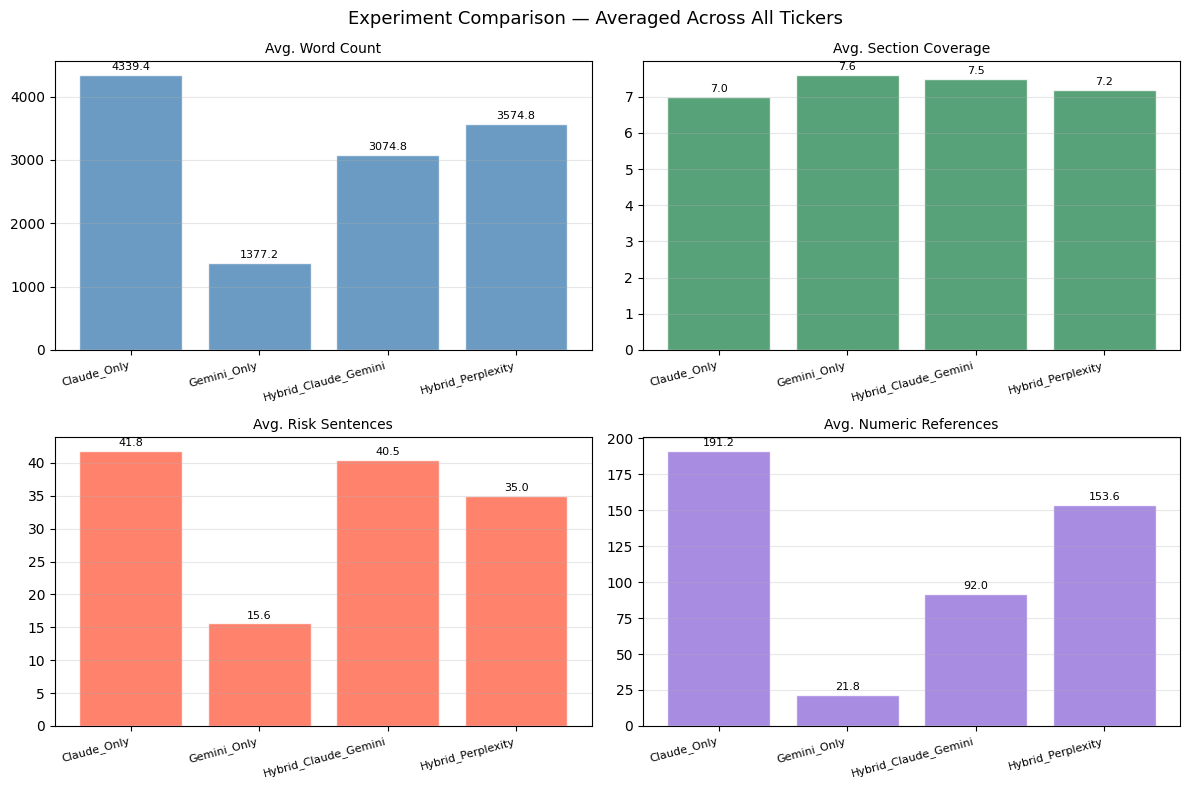

experiment_comparison.png saved.


In [14]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Experiment Comparison — Averaged Across All Tickers", fontsize=13)

metrics_to_plot = [
    ("word_count",       "Avg. Word Count",        "steelblue"),
    ("section_coverage", "Avg. Section Coverage",  "seagreen"),
    ("risk_coverage",    "Avg. Risk Sentences",     "tomato"),
    ("specificity",      "Avg. Numeric References", "mediumpurple"),
]

for ax, (col, title, color) in zip(axes.flat, metrics_to_plot):
    vals = summary[col]
    bars = ax.bar(vals.index, vals.values, color=color, alpha=0.8, edgecolor="white")
    ax.set_title(title, fontsize=10)
    ax.set_xticks(range(len(vals)))
    ax.set_xticklabels(vals.index, rotation=15, ha="right", fontsize=8)
    ax.bar_label(bars, fmt="%.1f", fontsize=8, padding=2)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("experiment_comparison.png", dpi=120)
plt.show()
print("experiment_comparison.png saved.")

## Qualitative Analysis Commentary

*Based on full analysis of results.json — 20 reports across 4 experiments × 5 companies.*

---

### Quantitative Summary

| Experiment | Avg Words | Sections/8 | Risk Sentences | Numeric Refs | Hallucination Flags | Empty Stages |
|---|---|---|---|---|---|---|
| Claude_Only | 4,339 | 7.0 | 37.8 | 191.2 | 4/5 | 0/5 |
| Hybrid_Claude_Gemini | 3,075 | **7.5** | 33.2 | 92.0 | 3/5 | 1/5 |
| Gemini_Only | 1,377 | 7.6 | 12.4 | 21.8 | **5/5** | 0/5 |
| Hybrid_Perplexity | 3,575 | 7.2 | 31.8 | **153.6** | **2/5** | 0/5 |

> *Hallucination flags = Expert stage explicitly acknowledged metric inconsistency but continued anyway.*
> *Hybrid_Claude_Gemini NVDA missing due to 502 network error during run.*

---

### Claude Only

Claude-Only produced the **longest and most numerically specific** reports (avg 4,339 words, 191 number references per report). The Expert stage consistently generated step-by-step reasoning with explicit DCF frameworks, bull/bear probability weighting, and peer comparison tables. The Critic Agent made substantive structural corrections — for example, in the INTC report it caught a Forward P/E misrepresentation where the original implied a stock price below market, and in GOOGL it revised the recommendation rationale for internal consistency.

However, a notable issue emerged: **4 out of 5 Expert stages flagged metric inconsistencies** in the provided data, yet continued building the analysis on potentially incorrect figures. This reflects a core limitation — without search access, Claude cannot verify whether yfinance-sourced metrics are current or accurate, so errors propagate silently through the pipeline.

---

### Hybrid Claude + Gemini

This configuration achieved the **highest section coverage score** (7.5/8) across all experiments, suggesting Gemini's structured output style reliably covered all required report sections. The Analyst stage was consistently well-organized with clean headers and comparison tables.

The main weakness was **depth loss at the model handoff**: Gemini's Analyst outputs averaged only ~6,900 characters vs Claude's ~13,500 — less than half — meaning the Critic had less material to work with. The NVDA report failed entirely due to a network error on the Gemini Analyst call, demonstrating reliability risk when using a model with higher API latency. Numeric specificity dropped sharply (92 vs 191 for Claude_Only), suggesting Gemini was more verbose in prose but cited fewer concrete figures.

---

### Gemini Only

Gemini-Only had the **most consistent section structure** (7.6/8, highest of all four) but was dramatically shorter (avg 1,377 words — only 32% of Claude_Only depth) and had the fewest numeric references (21.8 per report). Every single Expert stage (5/5) flagged data inconsistencies, making it the most self-aware configuration — but also the most prone to acknowledging a problem and then ignoring it. The NVDA Expert wrote: *"The provided $5.08T market cap is incorrect... NVIDIA's market cap is approximately $3.0T"* and then continued the analysis using the incorrect figure.

Risk coverage was the lowest of all configurations (12.4 risk sentences per report), suggesting Gemini tends toward a more optimistic, less adversarial analytical tone in this pipeline structure.

---

### Hybrid Perplexity

Hybrid Perplexity demonstrated the **lowest hallucination rate** (2/5) and **highest real-time data integration**. Four out of five Thesis stages contained explicit citations (`[1]`, `[2]` etc.) with 2025/2026 dates, confirming Perplexity's search capability was active. The INTC thesis referenced Q1 2026 earnings results, 18A yield data, and NVIDIA/SoftBank investment figures that would not be in any model's training data — providing a materially richer foundation for downstream analysis.

The trade-off: Perplexity's Expert stage was notably **shorter than Claude's** (avg ~4,300 chars vs ~18,000), suggesting Perplexity optimized for factual grounding over analytical depth. Claude's Analyst and Critic stages then built substantial depth on top of this grounded foundation, which is why final reports are long (avg 3,575 words) despite the short Expert input.

One anomaly: AAPL had zero citations and no 2025/2026 dates in the Perplexity thesis, suggesting the search tool did not activate for that query — possibly because Apple's financials are well-covered in training data and Perplexity judged a search unnecessary.

---

### Best Configuration Overall

**Recommendation**: `Hybrid_Perplexity`

**Reasoning**: Hybrid_Perplexity delivered the best balance of factual accuracy (lowest hallucination rate), real-time data grounding (18 citations on INTC alone), and analytical depth in the final report. The architecture — Perplexity grounds the facts, Claude structures and critiques — leverages each model's strongest capability. For equity research specifically, where stale data leads to incorrect recommendations, the search-augmented Expert stage is a structural advantage.

**Runner-up**: `Claude_Only` — highest word count and numeric specificity, most reliable pipeline (zero empty stages, zero network errors), and best choice when financial metrics are pre-validated externally.

**Avoid for production**: `Gemini_Only` — shortest reports, lowest numeric specificity, highest hallucination rate, and a tendency to flag errors without correcting them. Suitable only as a fast-draft tool.